<a href="https://colab.research.google.com/github/Devsah9051/BANK-CUSTOMER-CHURN-PREDICTION/blob/main/BANK_CUSTOMER_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BANK CUSTOMER CHURN PREDICTION :


In [3]:
#Importing the important libraries:
#Standaed libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#sklearn libraies:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Models libraries:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

#Metrics libraries :
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,recall_score,precision_score,classification_report,roc_auc_score,roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

#Display Setting :
sns.set_theme(style='whitegrid',palette='muted',font_scale=1.05)
pd.set_option('display.max_columns',200)

In [5]:
#Step 2:
#reading the dataset :
df=pd.read_csv("/content/Customer-Churn-Records.csv")
print("Shapes",df.shape)
print(df.head(15))

Shapes (10000, 18)
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0           1    15634602  Hargrave          619    France  Female   42   
1           2    15647311      Hill          608     Spain  Female   41   
2           3    15619304      Onio          502    France  Female   42   
3           4    15701354      Boni          699    France  Female   39   
4           5    15737888  Mitchell          850     Spain  Female   43   
5           6    15574012       Chu          645     Spain    Male   44   
6           7    15592531  Bartlett          822    France    Male   50   
7           8    15656148    Obinna          376   Germany  Female   29   
8           9    15792365        He          501    France    Male   44   
9          10    15592389        H?          684    France    Male   27   
10         11    15767821    Bearce          528    France    Male   31   
11         12    15737173   Andrews          497     Spain    Male   24   
12    

In [6]:
#Display the infromation and description of this dataset :
display(df.info())
display(df.describe().T)
print("-"*100)
print("NUll_count",df.isnull().sum())
print("-"*100)
print("Duplicate_count",df.duplicated().sum())
print("-"*100)
print("\n Exited Value Count:")
print(df['Exited'].value_counts(normalize=False))
print("\nExited Proportion:")
print(df['Exited'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

None

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


----------------------------------------------------------------------------------------------------
NUll_count RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64
----------------------------------------------------------------------------------------------------
Duplicate_count 0
----------------------------------------------------------------------------------------------------

 Exited Value Count:
Exited
0    7962
1    2038
Name: count, dtype: int64

Exited Proportion:
Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64


In [7]:
# splitiong the numerical columns and categorical columns:
num_cols=df.select_dtypes(include=["number"]).columns.tolist()
cat_cols=df.select_dtypes(include=["object"]).columns.tolist()
print("Numerical_columns",num_cols)
print("Categorical_columns",cat_cols)


Numerical_columns ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical_columns ['Surname', 'Geography', 'Gender', 'Card Type']


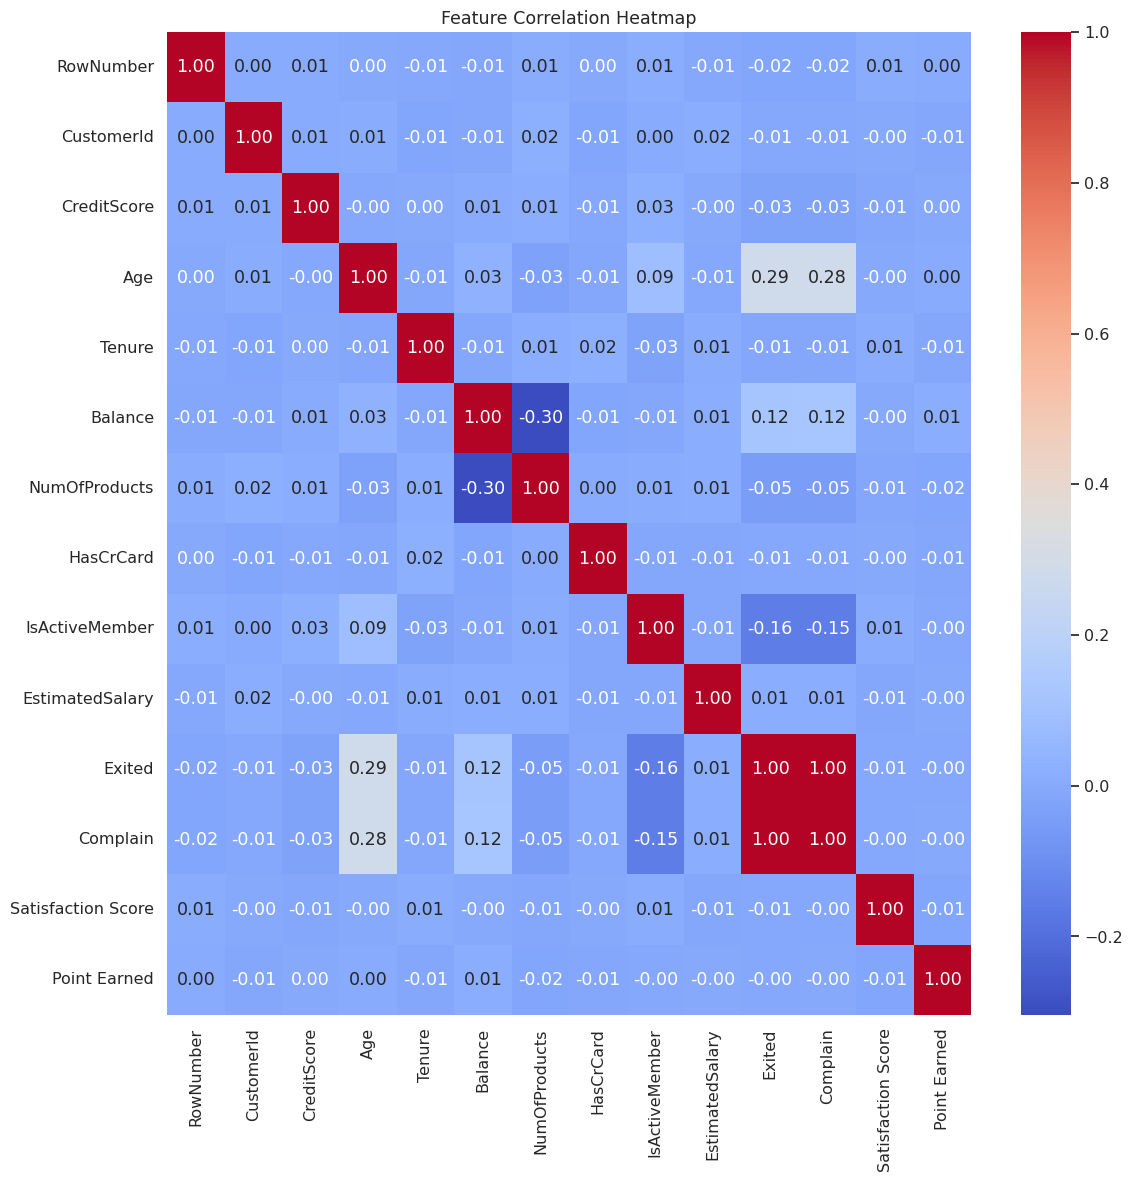

In [8]:
#plotting the heatmap on this checking the compatiblity of each columns with each other :
plt.figure(figsize=(12,12))
sns.heatmap(df[num_cols].corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

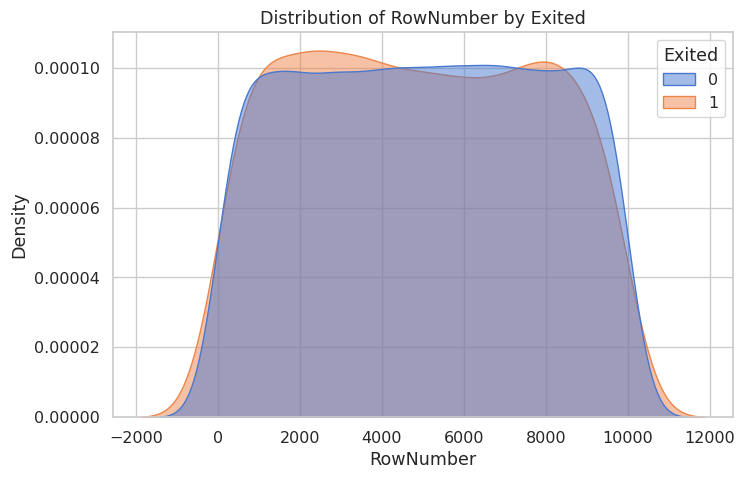

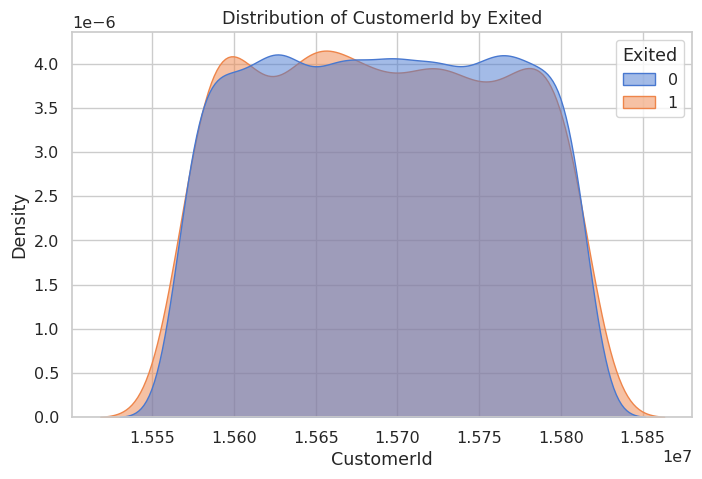

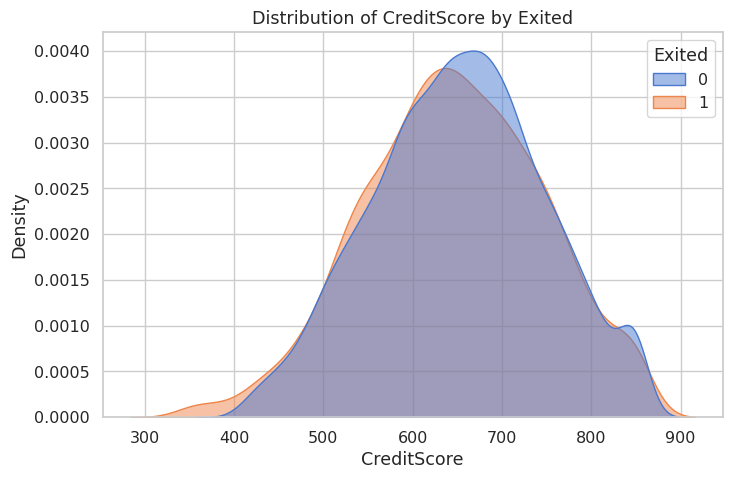

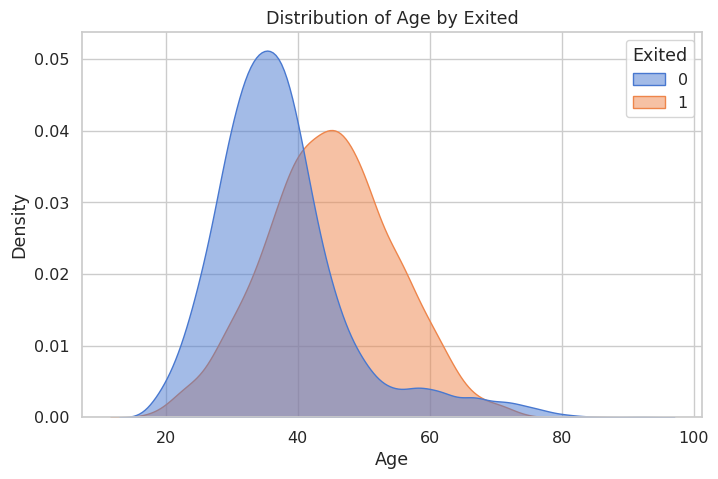

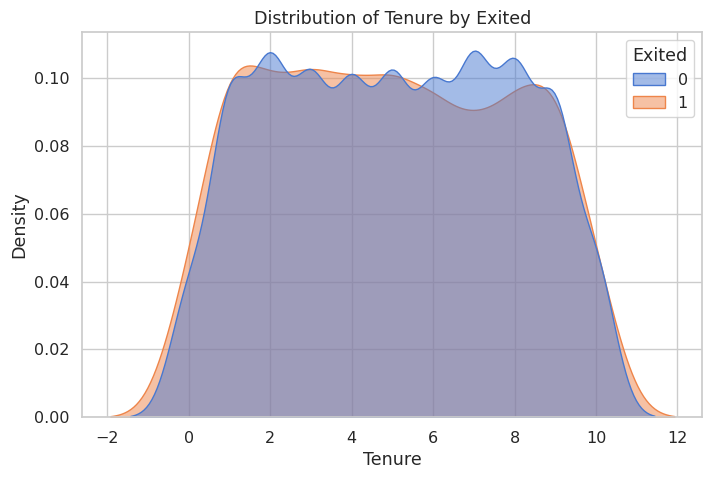

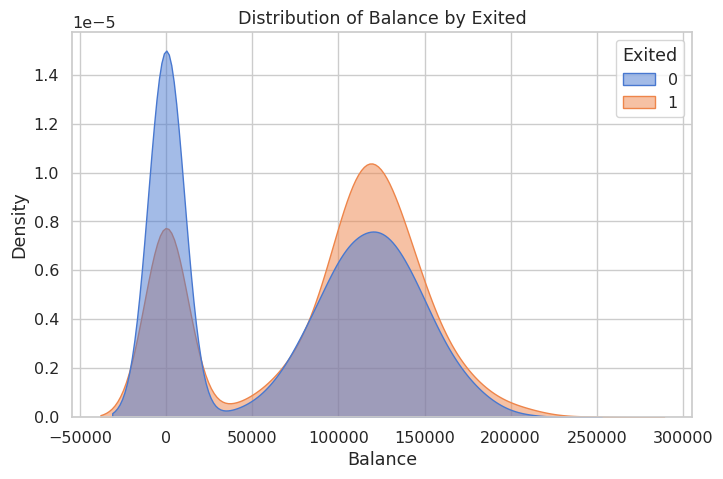

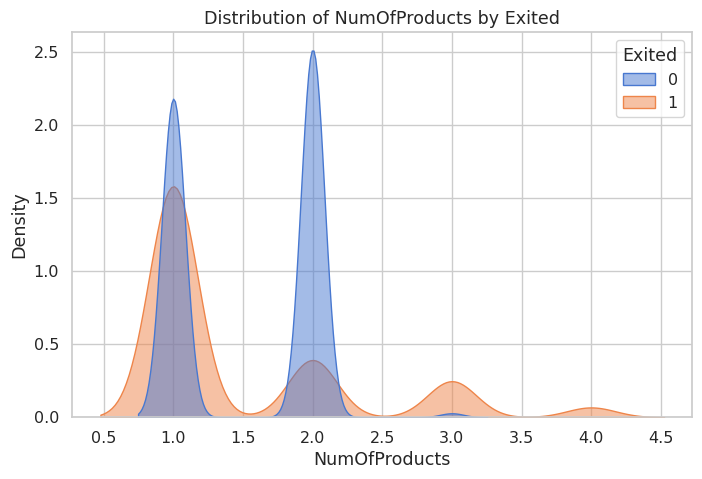

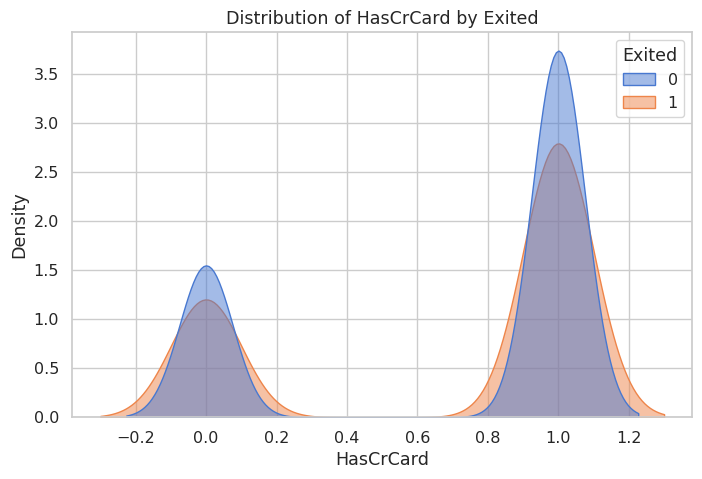

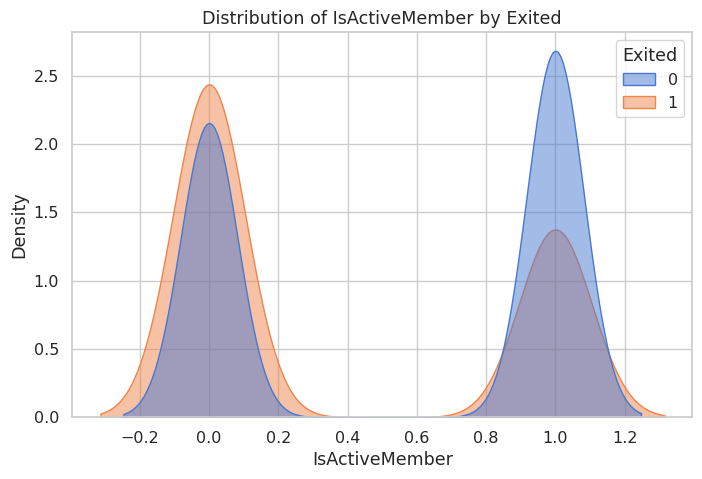

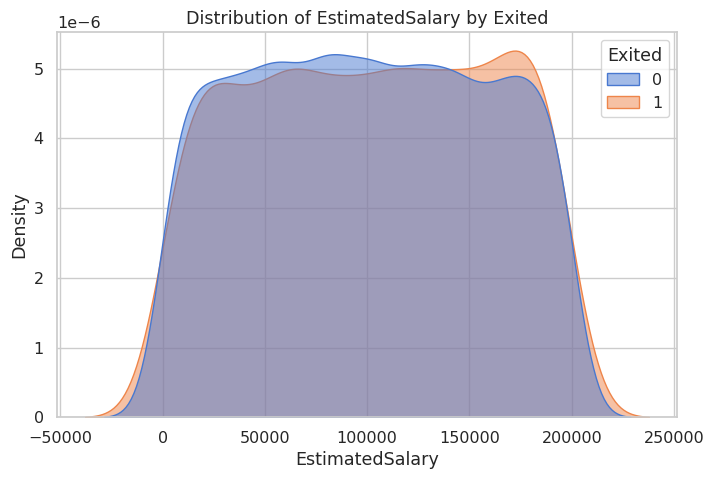

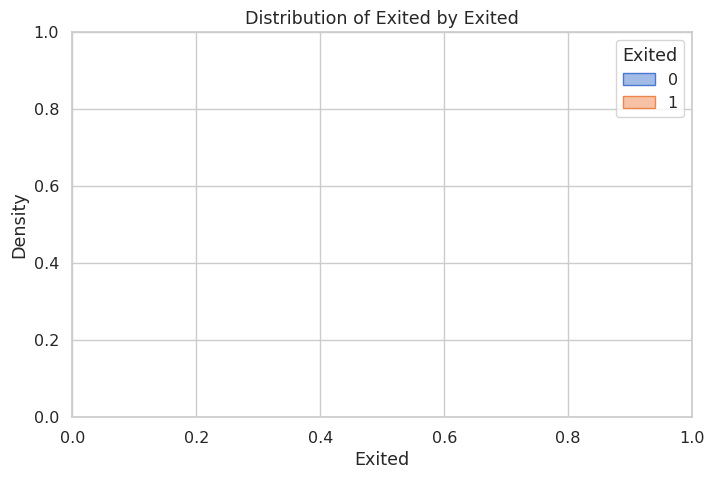

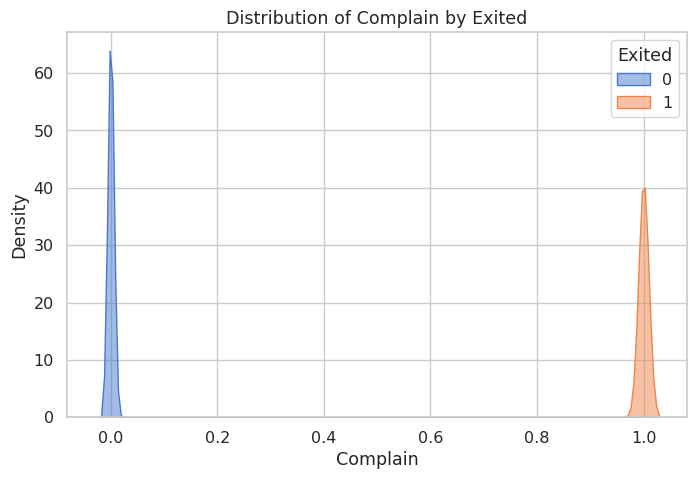

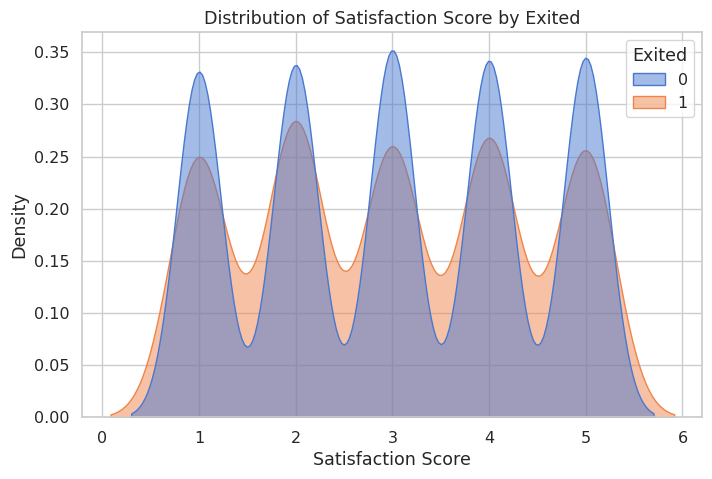

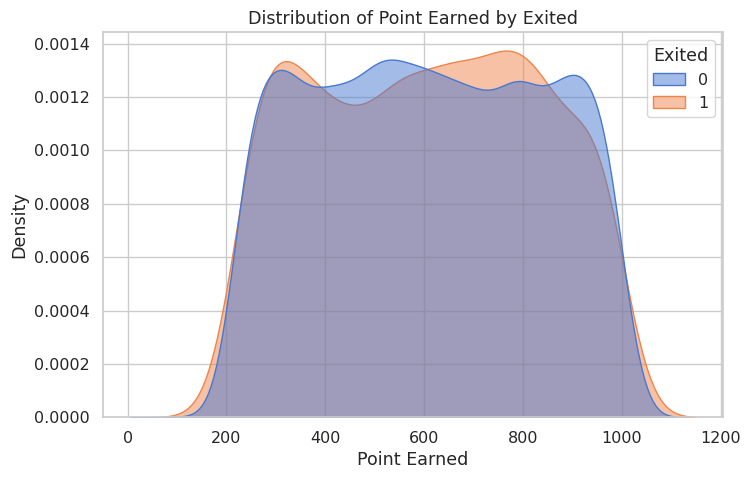

In [9]:
#plotting the kdeplot for checking the relationship between the numerical column:
for cols in num_cols:
  plt.figure(figsize=(8,5))
  sns.kdeplot(data=df,x=cols,hue='Exited',fill=True,common_norm=False,alpha=0.5)
  plt.title(f"Distribution of {cols} by Exited")
  plt.xlabel(cols)
  plt.ylabel("Density")
  plt.show()

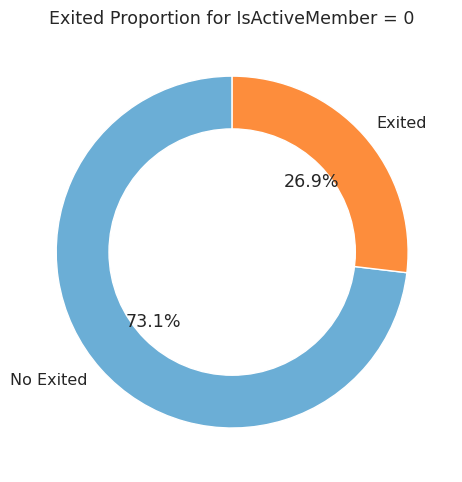

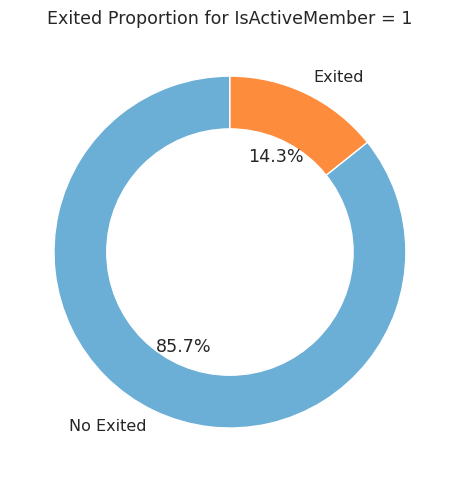

In [10]:
#donut chart between the IsActiveMember and Exited for better understanding of which exited more:
IsActiveMember_count=df.groupby('IsActiveMember')['Exited'].value_counts(normalize=True).unstack().fillna(0)
for IsActiveMembered in IsActiveMember_count.index:
  plt.figure(figsize=(5,5))
  plt.pie(IsActiveMember_count.loc[IsActiveMembered],labels=['No Exited','Exited'],autopct='%1.1f%%',startangle=90,colors=['#6baed6', '#fd8d3c'])
  center=plt.Circle((0,0),0.70,fc='white')
  fig=plt.gcf()
  fig.gca().add_artist(center)
  plt.title(f"Exited Proportion for IsActiveMember = {IsActiveMembered}")
  plt.tight_layout()
  plt.show()

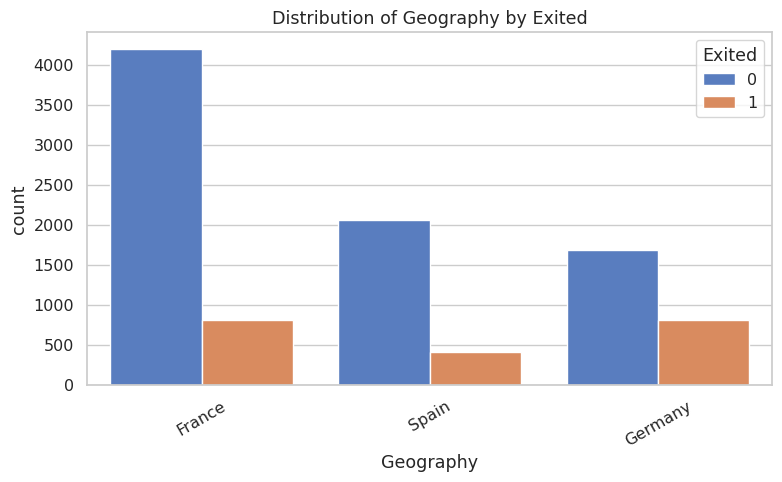

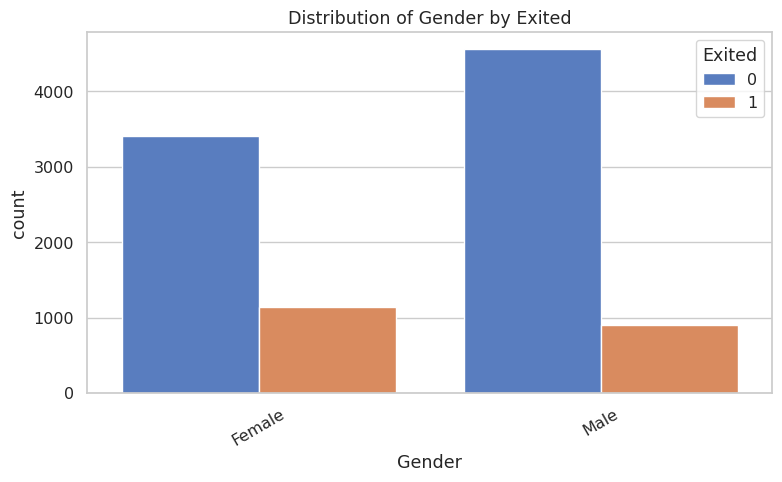

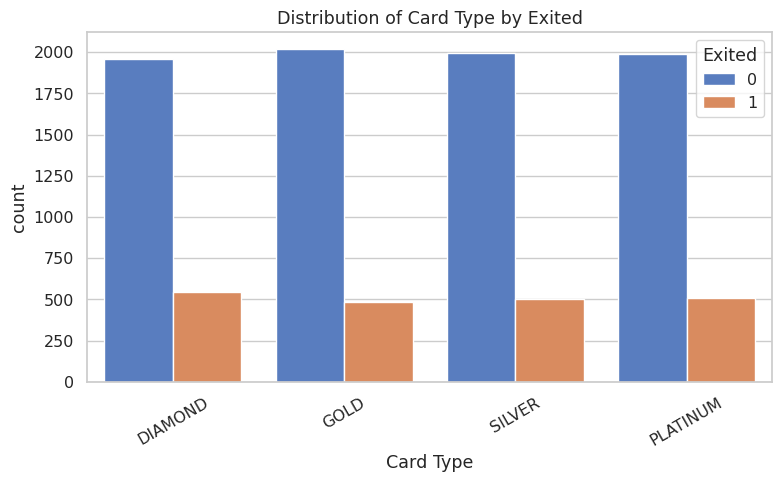

In [11]:
#plotting the graph based on the categorical dataset :
for cat in cat_cols:
  if cat == 'Surname':
    continue
  plt.figure(figsize=(8,5))
  sns.countplot(data=df,x=cat,hue='Exited')
  plt.title(f"Distribution of {cat} by Exited")
  plt.xticks(rotation =30)
  plt.tight_layout()
  plt.show()

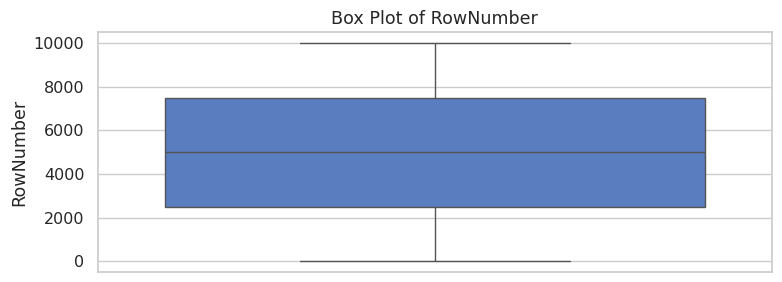

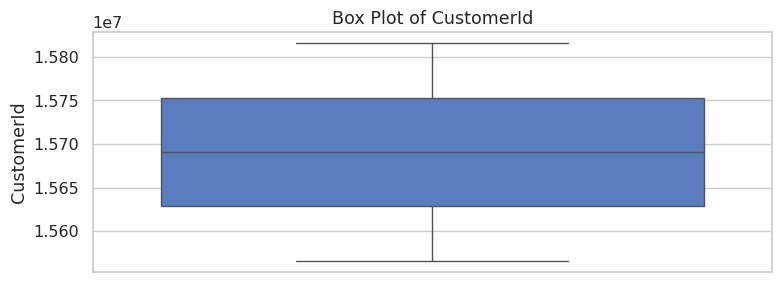

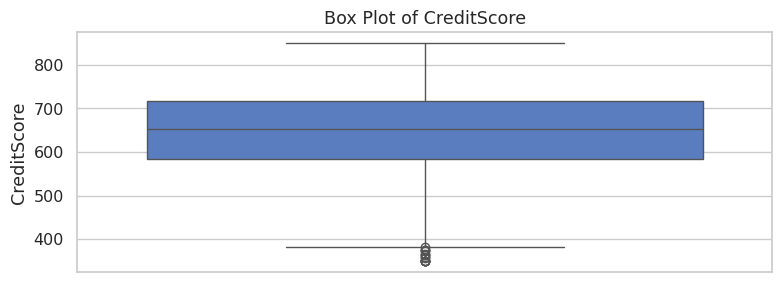

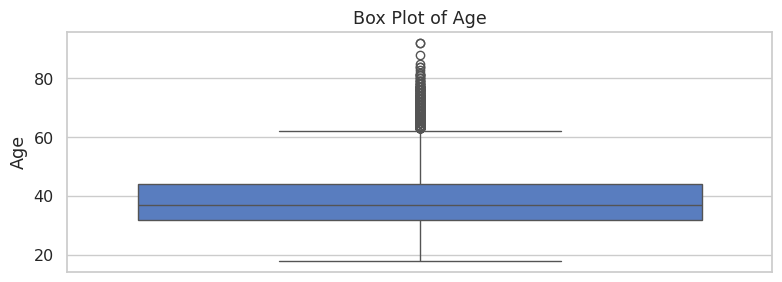

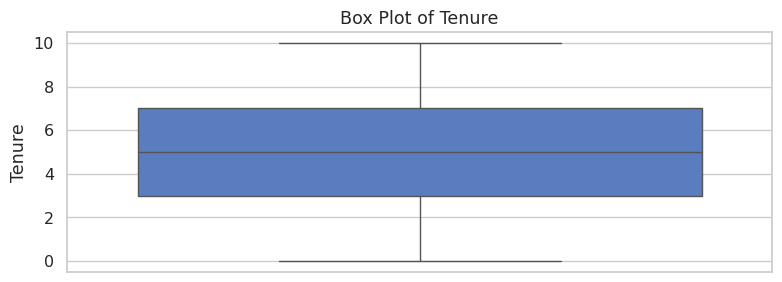

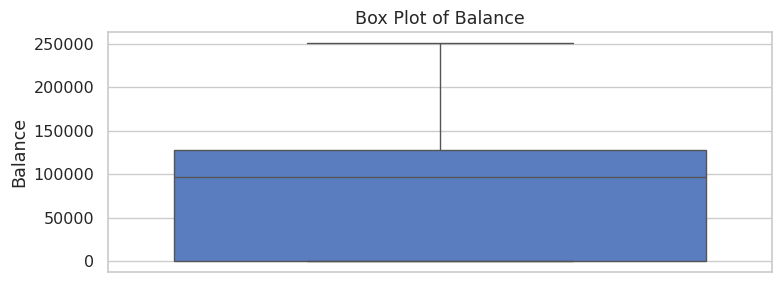

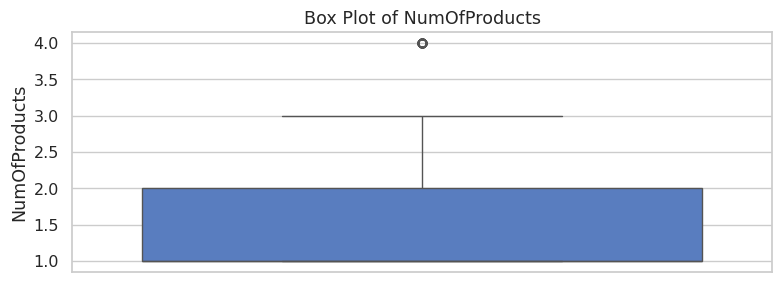

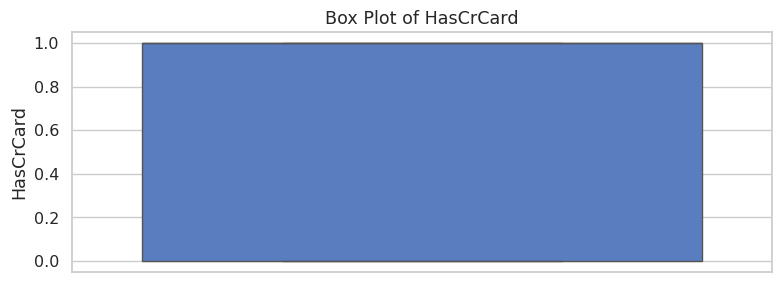

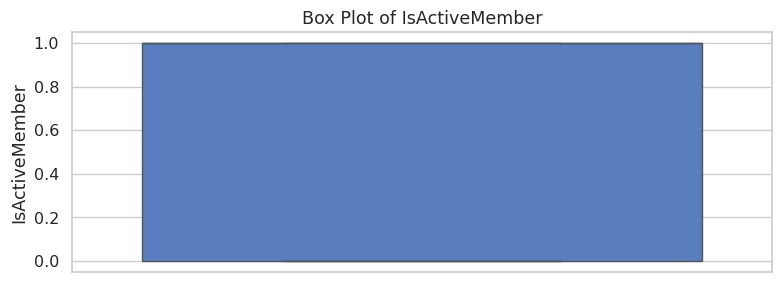

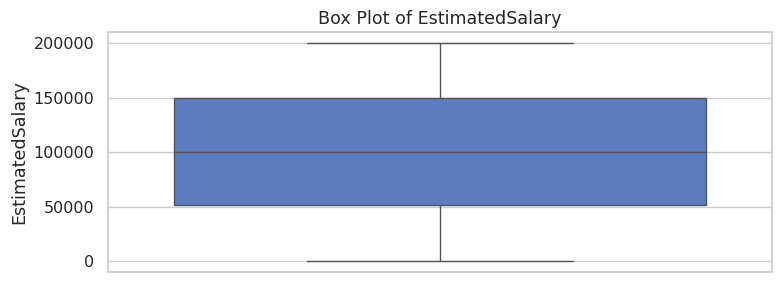

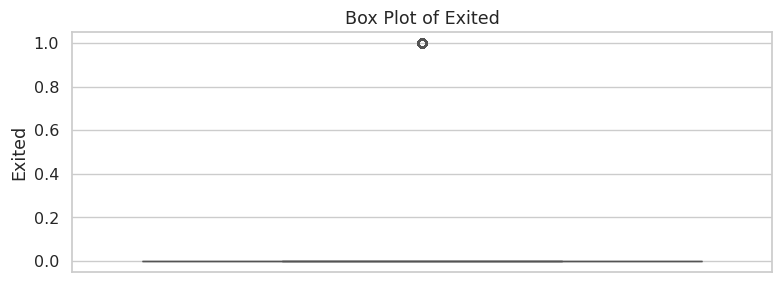

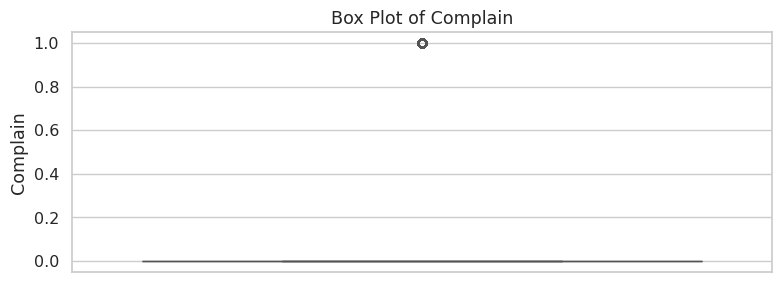

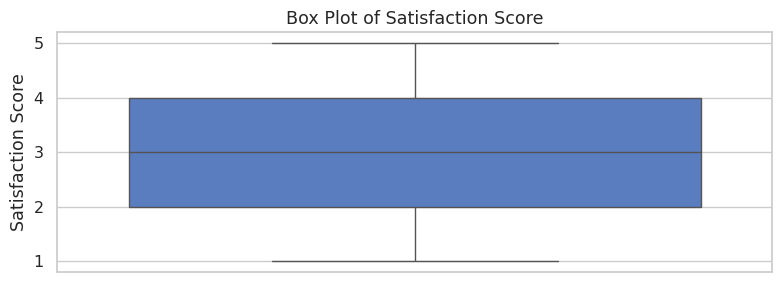

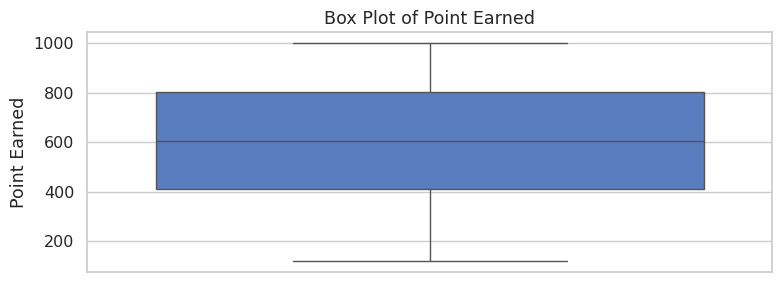

In [12]:
#checking the outlier in the dataset :
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



In [13]:
#checking the outlier i find some where i applyingh the IQR:
#columns have it :Age and credit score :
outlier_cols=['Age','CreditScore','NumOfProducts']

for cols in outlier_cols:
  Q1=df[cols].quantile(0.25)
  Q3=df[cols].quantile(0.75)
  iqr=Q3-Q1
  lower=Q1-1.5*iqr
  upper=Q3+1.5*iqr

  df[cols]=np.where(df[cols]<lower,lower,df[cols])
  df[cols]=np.where(df[cols]>upper,upper,df[cols])
  print(f"Outliers in '{cols}' handled using IQR method.\n New min: {df[cols].min():.2f}, new max: {df[cols].max():.2f}")


Outliers in 'Age' handled using IQR method.
 New min: 18.00, new max: 62.00
Outliers in 'CreditScore' handled using IQR method.
 New min: 383.00, new max: 850.00
Outliers in 'NumOfProducts' handled using IQR method.
 New min: 1.00, new max: 3.50



 Box plots after outlier capping :


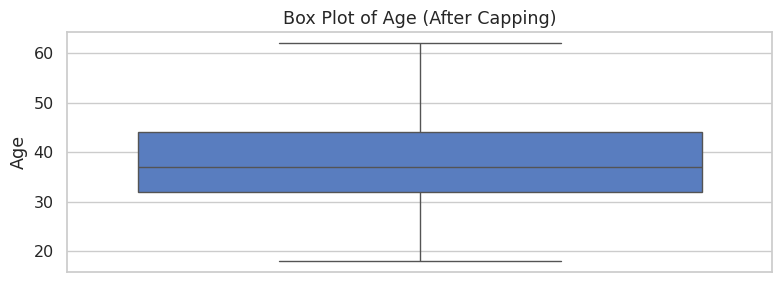

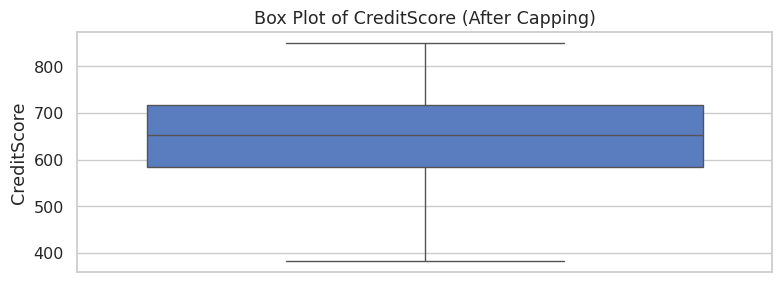

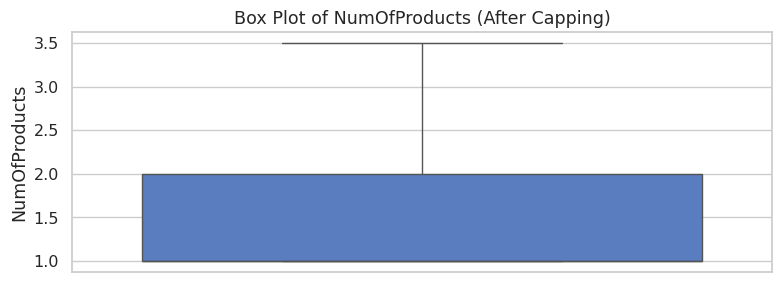

In [14]:
print("\n Box plots after outlier capping :")
for col in outlier_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Feature Engineering:


In [17]:
#creating nre feature which make more impact to detect exited :
df_new=df.copy()

#balance per porduct number:
df_new['balance_per_num_prod']=df_new['Balance']/(df_new['NumOfProducts'].replace(0,np.nan))
df_new['balance_per_num_prod'].fillna(0,inplace=True)
#credit score per age:
df_new['credit_score_per_age']=df_new['CreditScore']/df_new['Age'].replace(0,np.nan)
df_new['credit_score_per_age'].fillna(0,inplace=True)
#age group:
df_new['age_group']=pd.cut(df_new['Age'],bins=[0,25,35,45,55,65,100],labels=['<25','25-34','35-44','45-54','55,64','65+>'])
#tenure bucket:
df_new["Tenure_bucket"] = pd.cut(df_new["Tenure"], bins=[-1, 0, 2, 5, 8, 10, 100],labels=["0", "1-2", "3-5", "6-8", "9-10", "10+"])

In [18]:
#see the new dataset:
df_new.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,balance_per_num_prod,credit_score_per_age,age_group,Tenure_bucket
1723,1724,15567422,Chiazagomekpele,630.0,France,Male,42.0,6,0.00,2.0,1,0,162697.93,0,0,1,GOLD,986,0.00,15.000000,35-44,6-8
7886,7887,15744979,Fowler,666.0,France,Female,36.0,8,0.00,1.0,0,1,158666.99,0,0,3,GOLD,507,0.00,18.500000,35-44,6-8
9786,9787,15609521,Chimaraoke,803.0,Germany,Male,34.0,4,142929.16,2.0,1,1,114869.56,0,0,2,GOLD,325,71464.58,23.617647,25-34,3-5
7494,7495,15599272,Harrington,795.0,France,Female,36.0,1,151844.64,1.0,1,1,135388.89,0,0,3,SILVER,605,151844.64,22.083333,35-44,1-2
5127,5128,15644796,Dyer,821.0,Spain,Female,38.0,8,0.00,2.0,0,1,126241.40,1,1,2,PLATINUM,974,0.00,21.605263,35-44,6-8
1635,1636,15604804,Lu,516.0,France,Female,33.0,7,127305.50,1.0,1,1,120037.36,0,0,4,GOLD,924,127305.50,15.636364,25-34,6-8
3427,3428,15715079,Bold,465.0,France,Male,41.0,9,117221.15,1.0,1,0,168280.95,0,0,3,SILVER,495,117221.15,11.341463,35-44,9-10
5671,5672,15805104,Smith,743.0,France,Female,62.0,6,0.00,2.0,0,1,107867.38,0,0,4,GOLD,538,0.00,11.983871,"55,64",6-8
637,638,15583725,Mairinger,682.0,France,Male,48.0,1,138778.15,1.0,0,1,168840.23,0,0,5,SILVER,229,138778.15,14.208333,45-54,1-2
3037,3038,15741094,Sagese,693.0,France,Male,21.0,1,0.00,2.0,1,1,3494.02,0,0,3,PLATINUM,931,0.00,33.000000,<25,1-2


Proessing -Encoding & Scaling:


In [19]:
target='Exited'
drop_cols=['CustomerId']
features=[c for c in df_new.columns if c not in [target]+drop_cols]

# Redefine num_cols and cat_cols based on the features that will actually be used for training
# This ensures they are aligned with X and X_train
num_cols = df_new[features].select_dtypes(include=np.number).columns.tolist()
cat_cols = df_new[features].select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure categorical columns are of 'object' dtype (or 'category') for OneHotEncoder
for col in cat_cols:
    if col in df_new.columns:
        df_new[col] = df_new[col].astype('object')

numerica_transform=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('Scaler',StandardScaler())
])

categorical_transform=Pipeline([
  ('imputer',SimpleImputer(strategy='most_frequent')),
  ('Onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

preprocessor=ColumnTransformer([
    ('num',numerica_transform,num_cols),
    ('cat',categorical_transform,cat_cols)
])

print("Numerical Features:",num_cols)
print("Categorical Features:",cat_cols)

Numerical Features: ['RowNumber', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned', 'balance_per_num_prod', 'credit_score_per_age']
Categorical Features: ['Surname', 'Geography', 'Gender', 'Card Type', 'age_group', 'Tenure_bucket']


Train Test Split:


In [20]:
X=df_new[features]
y=df_new[target]


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (8000, 20)
X_test shape: (2000, 20)
y_train shape: (8000,)
y_test shape: (2000,)


# Model Selection:

In [21]:
from os import pipe
#Creating the model :
model_dict={
    'Logistic Regression':LogisticRegression(max_iter=500),
    'Random forest ':RandomForestClassifier(n_estimators=200,random_state=42),
    'GradientBossting': GradientBoostingClassifier(n_estimators=200,random_state=42),
    'AdaBoost':AdaBoostClassifier(n_estimators=200,random_state=42),
    'SVM':SVC(probability=True,random_state=42)
}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results={}


for name,model in model_dict.items():
  pipe=Pipeline([
      ('preprocessor',preprocessor),
      ('model',model)
  ])
  scores=cross_val_score(pipe,X_train,y_train,cv=cv,scoring='roc_auc',n_jobs=-1)

  results[name]=scores
  print(f"{name} Auc: Mean={scores.mean():.4f} Std={scores.std():.4f}")

# Identify the best model based on mean ROC AUC score
best_model_name = max(results, key=lambda name: results[name].mean())
best_model_obj = model_dict[best_model_name]

# Create the final best pipeline and fit it on the training data
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_obj)
])

best_pipeline.fit(X_train, y_train)
print(f"\nBest performing model: {best_model_name}")

Logistic Regression Auc: Mean=0.9994 Std=0.0006
Random forest  Auc: Mean=0.9996 Std=0.0003
GradientBossting Auc: Mean=0.9987 Std=0.0010
AdaBoost Auc: Mean=0.9986 Std=0.0014
SVM Auc: Mean=0.9993 Std=0.0004

Best performing model: Random forest 


# Testing the Model on random data:


In [24]:
#Crating smaple dataset for checking:

sample_data={
    'RowNumber': 0, # Placeholder
    'CustomerId':37325248,
    'Surname':'SampleSurname', # Placeholder
    'CreditScore':650,
    'Geography':'France',
    'Gender':'Male',
    'Age':40,
    'Tenure':5,
    'Balance':50000.0,
    'NumOfProducts':5,
    'HasCrCard':1,
    'IsActiveMember':1,
    'EstimatedSalary':600000.0,
    'Complain':0,
    'Satisfaction Score':3,
    'Card Type':'DIAMOND',
    'Point Earned':0
}

sample_df=pd.DataFrame([sample_data])
print(sample_df)
#balance per porduct number:
sample_df['balance_per_num_prod']=sample_df['Balance']/(sample_df['NumOfProducts'].replace(0,np.nan))
sample_df['balance_per_num_prod'].fillna(0,inplace=True)
#credit score per age:
sample_df['credit_score_per_age']=sample_df['CreditScore']/sample_df['Age'].replace(0,np.nan)
sample_df['credit_score_per_age'].fillna(0,inplace=True)
#age group:
sample_df['age_group']=pd.cut(sample_df['Age'],bins=[0,25,35,45,55,65,100],labels=['<25','25-34','35-44','45-54','55,64','65+>'])
#tenure bucket:
sample_df["Tenure_bucket"] = pd.cut(sample_df["Tenure"], bins=[-1, 0, 2, 5, 8, 10, 100],labels=["0", "1-2", "3-5", "6-8", "9-10", "10+"])

# Remove High_balance and High_credit_score as they are not in the 'features' list used for training
# If they were intended to be features, they should have been added to the 'features' list in uPGe5rO2i5xd
if 'High_balance' in sample_df.columns:
    sample_df = sample_df.drop(columns=['High_balance'])
if 'High_credit_score' in sample_df.columns:
    sample_df = sample_df.drop(columns=['High_credit_score'])

sample_df=sample_df.drop(columns=['CustomerId'])

# Re-align sample_df columns with the 'features' list from training
# This is crucial to match the input expected by the preprocessor and model.
if 'features' in globals(): # Check if 'features' list is defined in the environment
    # Create an empty DataFrame with the exact columns and order as 'features', filled with NaNs
    aligned_sample_df = pd.DataFrame(np.nan, index=[0], columns=features)

    # Populate the aligned_sample_df with values from the processed sample_df
    for col in sample_df.columns:
        if col in features: # Only copy columns that are in our model's features
            aligned_sample_df[col] = sample_df[col].iloc[0] # Copy value, assuming single row sample_df

    sample_df = aligned_sample_df

try:
    pred = best_pipeline.predict(sample_df)[0]
    prob = best_pipeline.predict_proba(sample_df)[0, 1]
    print(f"Predicted Exited: {pred}, Probability of Exited: {prob:.4f}")
except NameError:
    print("Error: 'best_pipeline' is still not found in your environment!")
    print(" Please run your Model Training cell first to define the pipeline variable.")

   RowNumber  CustomerId        Surname  CreditScore Geography Gender  Age  \
0          0    37325248  SampleSurname          650    France   Male   40   

   Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       5  50000.0              5          1               1         600000.0   

   Complain  Satisfaction Score Card Type  Point Earned  
0         0                   3   DIAMOND             0  
Predicted Exited: 0, Probability of Exited: 0.2950


Saving the best Model :

In [26]:
import pickle
pickle.dump(best_pipeline,open('best_model.pkl','wb'))